# MapClass / GeoViLM — Phase 1 Playground

Interactive surface for the Phase 1 walking skeleton. The pipeline is real (load checkpoint → preprocess → backbone → seg heads → softmax → WATER_TOPO overlay), but the **backbone is a learnable Mock** (Conv 3→32→64, ~30k params). Outputs are not semantically meaningful — Phase 2 swaps in SmolVLM-500M.

**What this notebook exercises:**
1. Load the smoke checkpoint (`models/geovilm_phase1_mock.pt`) via the public `load_model` API
2. Run `predict()` on a fixture and a real PNG and see the contract dict it returns
3. Visualize land_cover argmax + topography overlay (with WATER_TOPO=255 sentinel)
4. Trigger the taxonomy-hash-mismatch refusal on purpose to see the load-time guard fire
5. Inspect checkpoint metadata (model_version, dataset_manifest_sha, taxonomy_hash, training_seed, source_class_weights_hash, backbone, processor_identity)

**Pre-reqs already done by setup:** Phase 1 deps installed (`safetensors`, `omegaconf`, `tensorboard`), 100 fixture samples generated under `data/renders/`, smoke checkpoint at `models/geovilm_phase1_mock.pt`.

## 1. Setup

In [1]:
import os
os.environ['CUDA_VISIBLE_DEVICES'] = ''  # this VM's CUDA driver is broken; force CPU

import sys
from pathlib import Path

REPO = Path('/home/drdreadknee/mapclass')
if str(REPO) not in sys.path:
    sys.path.insert(0, str(REPO))

import json
import numpy as np
import torch
from PIL import Image
import matplotlib.pyplot as plt

from mapclass.infer import load_model
from mapclass.data.taxonomy import LANDCOVER_CLASSES, TOPO_CLASSES, taxonomy_hash, WATER_TOPO

print('LANDCOVER_CLASSES:', LANDCOVER_CLASSES)
print('TOPO_CLASSES:    ', TOPO_CLASSES)
print('WATER_TOPO:      ', WATER_TOPO)
print('taxonomy_hash:   ', taxonomy_hash())

LANDCOVER_CLASSES: ['water', 'trees', 'shrubland', 'grassland', 'cropland', 'built_up', 'bare_sparse', 'flooded_wetland', 'snow_ice']
TOPO_CLASSES:     ['flat', 'hilly', 'mountainous']
WATER_TOPO:       255
taxonomy_hash:    052624d2022aa6650b4ef09a519d86c3d4c8eb4a0fe8d7cbc683f3947a489e22


## 2. Load checkpoint + inspect metadata

In [2]:
predictor = load_model(REPO / 'models/geovilm_phase1_mock.pt', device='cpu')
print('Loaded predictor:', predictor)
print()
print('Checkpoint metadata (round-tripped, JSON-decoded):')
for k, v in predictor.metadata.items():
    print(f'  {k:30s} = {v}')

Loaded predictor: <mapclass.infer._Predictor object at 0x7e7b44168490>

Checkpoint metadata (round-tripped, JSON-decoded):
  dataset_manifest_sha           = 2ae11356e121c53eb8b81fed405e1324e769542e56b4862d4acb174566554e7e
  backbone                       = mock
  source_class_weights_hash      = 10f7e4dd4a3e7759152019721644939646f8b20f38dbde2385632b206c9c09ab
  processor_identity             = mock_passthrough
  model_version                  = 0.1.0
  taxonomy_hash                  = 052624d2022aa6650b4ef09a519d86c3d4c8eb4a0fe8d7cbc683f3947a489e22
  training_seed                  = 42


## 3. Predict on a fixture sample

These are synthetic — image RGB encodes the labels (R = land_cover class * 28; G = topography class * 80) so the Mock backbone has a learnable signal during smoke train.

In [7]:
sample_path = REPO / 'data/renders/sample_0099_rumsey_registered/image.png'
img = Image.open(sample_path)
print(f'Image: {img.size} {img.mode}')

result = predictor.predict(img)
print()
print('Result keys:', list(result.keys()))
print(f"  land_cover                       : {tuple(result['land_cover'].shape)}  sum_per_pixel={result['land_cover'].sum(0).mean().item():.6f}")
print(f"  topography                       : {tuple(result['topography'].shape)}  sum_per_pixel={result['topography'].sum(0).mean().item():.6f}")
print(f"  land_cover_argmax                : {tuple(result['land_cover_argmax'].shape)}  unique={result['land_cover_argmax'].unique().tolist()}")
print(f"  topography_label_with_overlay    : {tuple(result['topography_label_with_overlay'].shape)}  unique={result['topography_label_with_overlay'].unique().tolist()}")
print(f"  model_version                    : {result['model_version']}")

Image: (64, 64) RGB
  inference: image 64x64 (T-02-02: log dims at infer)

Result keys: ['land_cover', 'topography', 'land_cover_argmax', 'topography_label_with_overlay', 'model_version', 'taxonomy', 'metadata']
  land_cover                       : (9, 64, 64)  sum_per_pixel=1.000000
  topography                       : (3, 64, 64)  sum_per_pixel=1.000000
  land_cover_argmax                : (64, 64)  unique=[0, 1, 2, 3, 4, 5, 6, 7, 8]
  topography_label_with_overlay    : (64, 64)  unique=[0, 1, 2, 255]
  model_version                    : 0.1.0


## 4a. Visualize the data

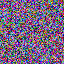

In [8]:
img

## 4b. Visualize the prediction

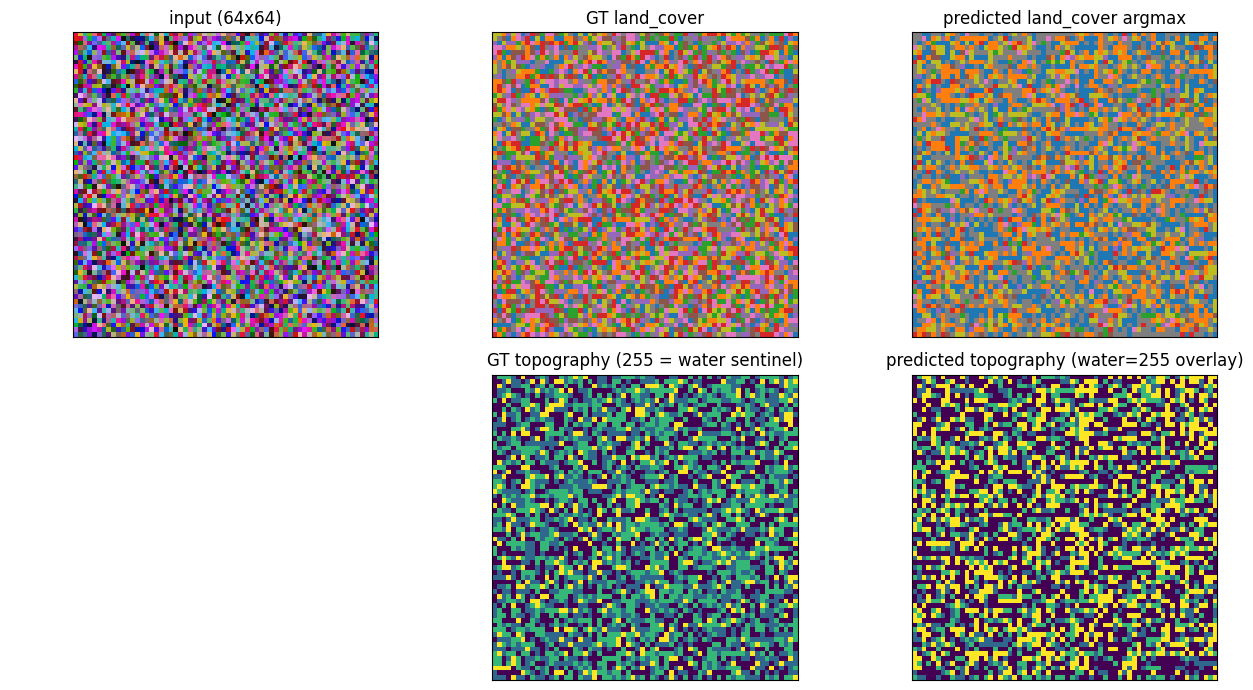

In [4]:
lc_argmax = result['land_cover_argmax'].numpy()
topo_overlay = result['topography_label_with_overlay'].numpy()
gt_lc = np.array(Image.open(sample_path.parent / 'land_cover.png'))
gt_topo = np.array(Image.open(sample_path.parent / 'topography.png'))

fig, axes = plt.subplots(2, 3, figsize=(13, 7))
axes[0, 0].imshow(np.array(img)); axes[0, 0].set_title(f'input ({img.size[0]}x{img.size[1]})')
axes[0, 1].imshow(gt_lc, cmap='tab10', vmin=0, vmax=9); axes[0, 1].set_title('GT land_cover')
axes[0, 2].imshow(lc_argmax, cmap='tab10', vmin=0, vmax=9); axes[0, 2].set_title('predicted land_cover argmax')
axes[1, 0].axis('off')
axes[1, 1].imshow(gt_topo, cmap='viridis', vmin=0, vmax=3); axes[1, 1].set_title('GT topography (255 = water sentinel)')
axes[1, 2].imshow(topo_overlay, cmap='viridis', vmin=0, vmax=3); axes[1, 2].set_title('predicted topography (water=255 overlay)')
for ax in axes.flat: ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()
plt.show()

## 5. Predict on an arbitrary image

Drop any RGB PNG/JPG below and re-run. The Mock backbone produces nonsensical predictions on real maps (Phase 2 fixes that with SmolVLM), but the contract surface is identical.

In [ ]:
# Replace this with a path to your own map image:
TEST_IMAGE = REPO / 'data/renders/sample_0042_synthetic_azgaar/flat.png'

if TEST_IMAGE.exists():
    img = Image.open(TEST_IMAGE).convert('RGB')
    out = predictor.predict(img)
    fig, axes = plt.subplots(1, 3, figsize=(13, 4))
    axes[0].imshow(np.array(img)); axes[0].set_title(f'{TEST_IMAGE.name} ({img.size[0]}x{img.size[1]})')
    axes[1].imshow(out['land_cover_argmax'].numpy(), cmap='tab10', vmin=0, vmax=9); axes[1].set_title('predicted land_cover')
    axes[2].imshow(out['topography_label_with_overlay'].numpy(), cmap='viridis', vmin=0, vmax=3); axes[2].set_title('predicted topography')
    for ax in axes: ax.set_xticks([]); ax.set_yticks([])
    plt.tight_layout(); plt.show()
else:
    print(f'No image at {TEST_IMAGE} — drop a file there or change TEST_IMAGE.')

## 6. Per-class probability inspection

Look at the full softmax distribution at one pixel — useful for understanding what the downstream hex-grid app will consume.

In [ ]:
img = Image.open(REPO / 'data/renders/sample_0001_rumsey_registered/image.png')
result = predictor.predict(img)
lc_probs = result['land_cover']  # (9, H, W)
topo_probs = result['topography']  # (3, H, W)

# Pick the center pixel
h, w = lc_probs.shape[1] // 2, lc_probs.shape[2] // 2
print(f'Pixel ({h}, {w}) probabilities:')
print('  Land cover:')
for cls, p in zip(LANDCOVER_CLASSES, lc_probs[:, h, w].tolist()):
    bar = '█' * int(p * 40)
    print(f'    {cls:18s} {p:.4f} {bar}')
print('  Topography:')
for cls, p in zip(TOPO_CLASSES, topo_probs[:, h, w].tolist()):
    bar = '█' * int(p * 40)
    print(f'    {cls:18s} {p:.4f} {bar}')

## 7. Trigger the taxonomy-hash-mismatch guard

The `load_model` function refuses to load a checkpoint whose `taxonomy_hash` doesn't match the live taxonomy (PITFALL 4 prevention #3). Manually corrupt the metadata to see the guard fire.

In [ ]:
from safetensors import safe_open
from safetensors.torch import save_file
import shutil

src = REPO / 'models/geovilm_phase1_mock.pt'
tampered = REPO / 'models/_tampered_taxonomy.pt'

with safe_open(str(src), framework='pt') as f:
    state = {k: f.get_tensor(k) for k in f.keys()}
    raw_meta = dict(f.metadata() or {})

raw_meta['taxonomy_hash'] = json.dumps('deadbeef_not_the_real_hash')
save_file(state, str(tampered), metadata=raw_meta)

try:
    load_model(tampered, device='cpu')
    print('UNEXPECTED: load_model accepted tampered checkpoint!')
except Exception as e:
    print(f'Guard fired as expected:')
    print(f'  {type(e).__name__}: {e}')
finally:
    tampered.unlink(missing_ok=True)

## 8. Where to go next

- **Real predictions** land in Phase 2 when SmolVLM-500M replaces the Mock backbone. Until then, all numerical outputs are essentially noise filtered through random conv weights.
- The eval CLI (`python -m mapclass.eval --checkpoint ... --split heldout`) computes per-source per-class NLL — not meaningful as a *score* on Mock, but the *pipeline* is real and Phase 2 will surface real numbers through the same path.
- The contract surface (`predictor.predict(image)` → dict with `land_cover`, `topography`, etc.) is the stable interface the downstream hex-grid app will consume; Phase 2-6 won't change its shape, only the quality of the numbers.